**Exercise**

<img src='iris.png' width=200 height='100'/>

Use famous iris flower dataset from sklearn.datasets to predict flower species using random forest classifier.
1. Measure prediction score using default n_estimators (10)
2. Now fine tune your model by changing number of trees in your classifer and tell me what best score you can get using how many trees

In [1]:
from sklearn.datasets import load_iris

dataset=load_iris()

In [2]:
dir(dataset)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
import pandas as pd

df=pd.DataFrame(dataset.data,columns=dataset.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df["target"]=dataset.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
X=df.drop(["target"],axis="columns")
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
y=df["target"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [8]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=200)




In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [10]:
len(X_train)

120

In [11]:
len(X_test)

30

In [12]:
model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
model.score(X_test,y_test)

0.9666666666666667

In [14]:
y_predicted=model.predict(X_test)

In [15]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_predicted)
cm

array([[10,  0,  0],
       [ 0, 12,  1],
       [ 0,  0,  7]])

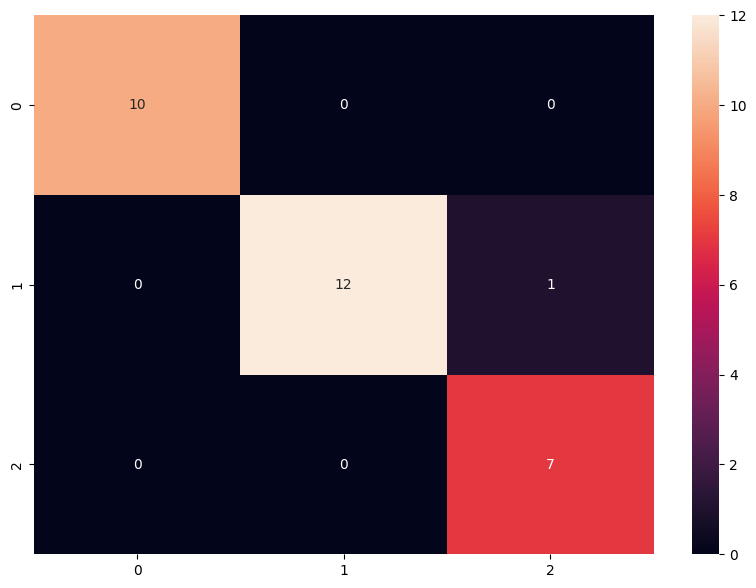

In [16]:
import matplotlib.pyplot as plt
import seaborn as sn

plt.figure(figsize=(10,7))
plt.xlabel("predicted value")
plt.ylabel("True value")
sn.heatmap(cm,annot=True)
plt.show()